# 🧠 Student Performance Classification
### Libraries Used: Python, NumPy, Pandas, Matplotlib, Scikit-learn

In [1]:
# Step 1: Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Set random seed for reproducibility
np.random.seed(42)

In [2]:
# Step 2: Create a synthetic dataset
num_students = 100
data = {
    "Student_ID": range(1, num_students + 1),
    "Hours_Studied": np.random.normal(5, 2, num_students).round(1),
    "Attendance_Rate": np.random.normal(75, 10, num_students).round(1),
    "Assignment_Score": np.random.randint(50, 100, num_students),
    "Final_Exam_Score": np.random.randint(30, 100, num_students)
}
df = pd.DataFrame(data)

# Add Pass column
df['Pass'] = np.where(df['Final_Exam_Score'] >= 50, 1, 0)

# Introduce missing values
df.loc[np.random.choice(df.index, 5), 'Hours_Studied'] = np.nan
df.loc[np.random.choice(df.index, 3), 'Attendance_Rate'] = np.nan

In [3]:
# Step 3: Data Inspection
print("📌 First 5 records:\n", df.head())
print("\n✅ Shape of dataset:", df.shape)
print("\n🔍 Checking for missing values:\n", df.isnull().sum())

📌 First 5 records:
    Student_ID  Hours_Studied  Attendance_Rate  Assignment_Score  \
0           1            6.0             60.8                51   
1           2            4.7             70.8                75   
2           3            6.3             71.6                66   
3           4            8.0             67.0                89   
4           5            4.5             73.4                82   

   Final_Exam_Score  Pass  
0                91     1  
1                98     1  
2                45     0  
3                77     1  
4                68     1  

✅ Shape of dataset: (100, 6)

🔍 Checking for missing values:
 Student_ID          0
Hours_Studied       5
Attendance_Rate     3
Assignment_Score    0
Final_Exam_Score    0
Pass                0
dtype: int64


In [4]:
# Step 4: Handle Missing Values
df['Hours_Studied'].fillna(df['Hours_Studied'].mean(), inplace=True)
df['Attendance_Rate'].fillna(df['Attendance_Rate'].mean(), inplace=True)

In [5]:
# Step 5: NumPy Manipulation
score_array = df[['Assignment_Score', 'Final_Exam_Score']].values
df['Mean_Score'] = np.mean(score_array, axis=1)
df['Std_Dev_Score'] = np.std(score_array, axis=1)

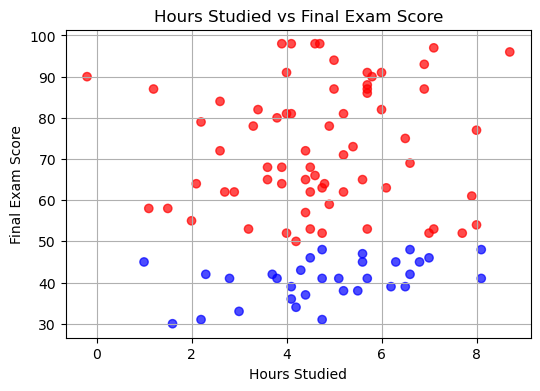

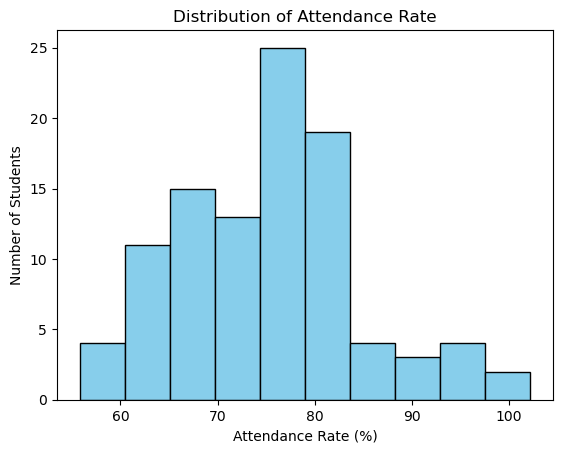

In [6]:
# Step 6: Data Visualization
plt.figure(figsize=(6, 4))
plt.scatter(df['Hours_Studied'], df['Final_Exam_Score'], c=df['Pass'], cmap='bwr', alpha=0.7)
plt.xlabel('Hours Studied')
plt.ylabel('Final Exam Score')
plt.title('Hours Studied vs Final Exam Score')
plt.grid(True)
plt.show()

plt.hist(df['Attendance_Rate'], bins=10, color='skyblue', edgecolor='black')
plt.title('Distribution of Attendance Rate')
plt.xlabel('Attendance Rate (%)')
plt.ylabel('Number of Students')
plt.show()

In [6]:
# Step 7: Model Building
features = ['Hours_Studied', 'Attendance_Rate', 'Assignment_Score']
target = 'Pass'
X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [8]:
# Step 8: Evaluation
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
conf = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("✅ Accuracy Score:", acc)
print("\n📊 Confusion Matrix:\n", conf)
print("\n📝 Classification Report:\n", report)

✅ Accuracy Score: 0.65

📊 Confusion Matrix:
 [[ 0  7]
 [ 0 13]]

📝 Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         7
           1       0.65      1.00      0.79        13

    accuracy                           0.65        20
   macro avg       0.33      0.50      0.39        20
weighted avg       0.42      0.65      0.51        20



C:\Users\SUPER\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\SUPER\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\SUPER\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


### 📌 Conclusion:
This notebook demonstrated a complete classification pipeline using:
- A synthetic education dataset
- Pandas for data handling
- NumPy for numerical operations
- Matplotlib for visualization
- Scikit-learn for modeling and evaluation

Feel free to experiment by changing the model or visualizing different relationships.